<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/21_09_ModuloII_C%C3%83ESeGATOS2_CNN_CLASSIFICA%C3%87%C3%83O.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXERCÍCIO GUIADO — CNN: CLASSIFICAÇÃO DE CÃES E GATOS
# Pipeline: ZIP -> organização -> treino/validação/teste -> CNN
# -> checkpoint -> avaliação -> 5 acertos e 5 erros


In [ ]:
# ETAPA 1 — IMPORTAR AS BIBLIOTECAS

import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

In [2]:
from google.colab import files
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

# ETAPA 2 — FAZER UPLOAD DO ARQUIVO ZIP

In [3]:
# Ao executar esta parte no Google Colab, clique em
# "Escolher arquivos" e selecione o arquivo .zip do dataset.

uploaded = files.upload()

# Pega automaticamente o nome do arquivo enviado.
zip_path = list(uploaded.keys())[0]

print("Arquivo enviado:", zip_path)

Saving caes_gatos.zip to caes_gatos.zip
Arquivo enviado: caes_gatos.zip


# ETAPA 3 — DESCOMPACTAR O DATASET

In [4]:
pasta_extraida = "/content/dataset_original"

# Apaga a pasta antiga, caso o código seja executado novamente.
if os.path.exists(pasta_extraida):
    shutil.rmtree(pasta_extraida)

os.makedirs(pasta_extraida)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(pasta_extraida)

print("Dataset descompactado!")
print("Conteúdo inicial:", os.listdir(pasta_extraida)[:10])

Dataset descompactado!
Conteúdo inicial: ['dogs_set', 'cats_set']


# ETAPA 4 — LOCALIZAR AS IMAGENS DE CÃES E GATOS

In [5]:
# O código procura arquivos com nomes semelhantes a:
# cat.0.jpg
# dog.0.jpg
#
# A busca é feita também dentro de subpastas, caso o ZIP
# tenha criado uma pasta chamada "train".

imagens_gatos = []
imagens_caes = []

for raiz, pastas, arquivos in os.walk(pasta_extraida):
    for arquivo in arquivos:

        nome = arquivo.lower()

        if nome.startswith("cat.") and nome.endswith((".jpg", ".jpeg", ".png")):
            imagens_gatos.append(os.path.join(raiz, arquivo))

        elif nome.startswith("dog.") and nome.endswith((".jpg", ".jpeg", ".png")):
            imagens_caes.append(os.path.join(raiz, arquivo))

print("Total de gatos encontrados:", len(imagens_gatos))
print("Total de cachorros encontrados:", len(imagens_caes))

Total de gatos encontrados: 500
Total de cachorros encontrados: 500


# ETAPA 5 — EMBARALHAR AS IMAGENS

In [6]:
# Usamos uma semente fixa para que a divisão possa ser
# reproduzida novamente.

random.seed(123)

random.shuffle(imagens_gatos)
random.shuffle(imagens_caes)


# ETAPA 6 — CRIAR TREINO, VALIDAÇÃO E TESTE

In [7]:
# Divisão utilizada:
#
# 70% -> Treino
# 15% -> Validação
# 15% -> Teste
#
# A separação é feita individualmente para cada classe.
# Assim mantemos gatos e cachorros distribuídos entre
# os três conjuntos.

def dividir_dados(lista):

    total = len(lista)

    fim_treino = int(total * 0.70)
    fim_validacao = int(total * 0.85)

    treino = lista[:fim_treino]
    validacao = lista[fim_treino:fim_validacao]
    teste = lista[fim_validacao:]

    return treino, validacao, teste


gatos_treino, gatos_val, gatos_teste = dividir_dados(imagens_gatos)
caes_treino, caes_val, caes_teste = dividir_dados(imagens_caes)


# ETAPA 7 — CRIAR A ESTRUTURA DE PASTAS

In [8]:
# dataset_final/
#
# ├── train/
# │   ├── cats/
# │   └── dogs/
# │
# ├── validation/
# │   ├── cats/
# │   └── dogs/
# │
# └── test/
#     ├── cats/
#     └── dogs/

dataset_final = "/content/dataset_final"

if os.path.exists(dataset_final):
    shutil.rmtree(dataset_final)

pastas = [
    "train/cats",
    "train/dogs",
    "validation/cats",
    "validation/dogs",
    "test/cats",
    "test/dogs"
]

for pasta in pastas:
    os.makedirs(os.path.join(dataset_final, pasta), exist_ok=True)

# ETAPA 8 — COPIAR AS IMAGENS PARA AS PASTAS

In [9]:
def copiar_imagens(lista, destino):

    for caminho in lista:
        shutil.copy2(caminho, destino)


copiar_imagens(gatos_treino, dataset_final + "/train/cats")
copiar_imagens(caes_treino, dataset_final + "/train/dogs")

copiar_imagens(gatos_val, dataset_final + "/validation/cats")
copiar_imagens(caes_val, dataset_final + "/validation/dogs")

copiar_imagens(gatos_teste, dataset_final + "/test/cats")
copiar_imagens(caes_teste, dataset_final + "/test/dogs")

print("Separação concluída!")

Separação concluída!


# ETAPA 9 — CONFERIR A QUANTIDADE DE IMAGENS

In [10]:
print("\nTREINO")
print("Gatos:", len(os.listdir(dataset_final + "/train/cats")))
print("Cachorros:", len(os.listdir(dataset_final + "/train/dogs")))

print("\nVALIDAÇÃO")
print("Gatos:", len(os.listdir(dataset_final + "/validation/cats")))
print("Cachorros:", len(os.listdir(dataset_final + "/validation/dogs")))

print("\nTESTE")
print("Gatos:", len(os.listdir(dataset_final + "/test/cats")))
print("Cachorros:", len(os.listdir(dataset_final + "/test/dogs")))




TREINO
Gatos: 350
Cachorros: 350

VALIDAÇÃO
Gatos: 75
Cachorros: 75

TESTE
Gatos: 75
Cachorros: 75


# ETAPA 10 — CARREGAR OS DATASETS COM O KERAS

In [11]:
# Todas as imagens serão redimensionadas para 150 x 150.
# batch_size = 32 significa que o modelo trabalha com
# grupos de 32 imagens por vez.

img_size = (150, 150)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_final + "/train",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_final + "/validation",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_final + "/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses encontradas:", class_names)


Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.

Classes encontradas: ['cats', 'dogs']


# ETAPA 11 — VISUALIZAR ALGUMAS IMAGENS

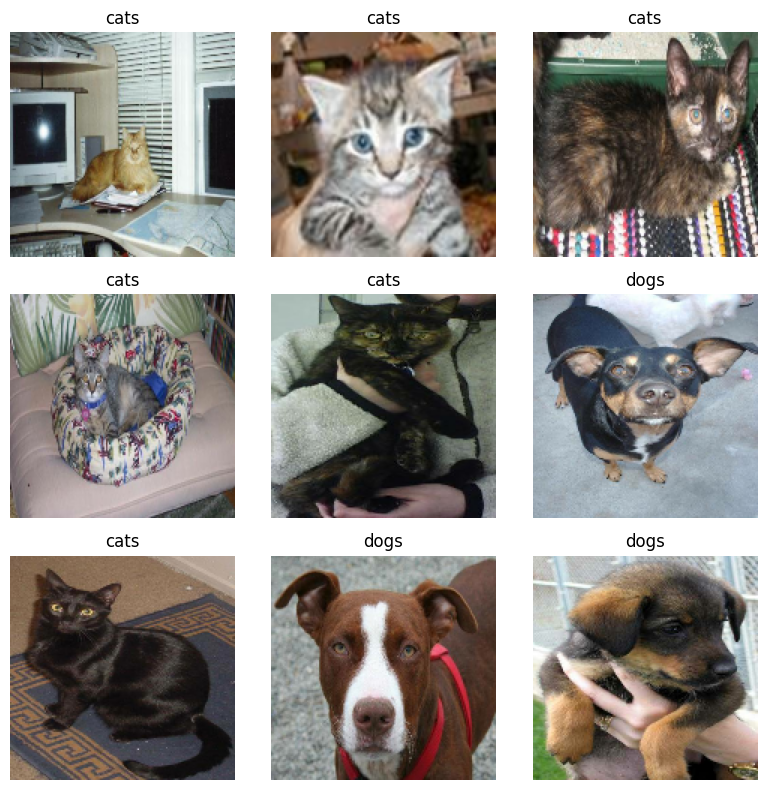

In [12]:
plt.figure(figsize=(8, 8))

for imagens, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(imagens[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

# ETAPA 12 — CRIAR A REDE NEURAL CONVOLUCIONAL (CNN)

In [13]:
# Rescaling:
# transforma pixels de 0-255 para valores entre 0-1.
#
# Conv2D:
# procura características nas imagens.
#
# MaxPooling2D:
# reduz o tamanho das informações.
#
# Flatten:
# transforma os mapas de características em um vetor.
#
# Dense:
# realiza a classificação.
#
# Sigmoid:
# usada porque temos duas classes: gatos e cachorros.

model = models.Sequential([

    layers.Input(shape=(150, 150, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

# ETAPA 13 — COMPILAR O MODELO

In [14]:
# Adam:
# ajusta os pesos da rede.
#
# binary_crossentropy:
# mede o erro em uma classificação com duas classes.
#
# accuracy:
# mede a porcentagem de acertos.

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ETAPA 14 — MOSTRAR A ESTRUTURA DA CNN

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# ETAPA 15 — CRIAR O CHECKPOINT

In [16]:
# O checkpoint salva o modelo que apresentar o MENOR
# erro de validação (val_loss).

checkpoint = ModelCheckpoint(
    "/content/melhor_modelo.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# ETAPA 16 — TREINAR A CNN

In [17]:
# Uma época significa uma passagem completa pelos dados
# de treinamento.
#
# O conjunto de teste NÃO é utilizado nesta etapa.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4956 - loss: 0.9042
Epoch 1: val_loss improved from None to 0.69189, saving model to /content/melhor_modelo.keras

Epoch 1: finished saving model to /content/melhor_modelo.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4957 - loss: 0.7741 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4931 - loss: 0.6932
Epoch 2: val_loss improved from 0.69189 to 0.69000, saving model to /content/melhor_modelo.keras

Epoch 2: finished saving model to /content/melhor_modelo.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5229 - loss: 0.6928 - val_accuracy: 0.6400 - val_loss: 0.6900
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6472 - loss: 0.6845
Epoch 3: val_loss improved from 0.69000 to 0.68186, saving model to /content/melhor_modelo.keras

Epoch 3: finished saving model to /content/melhor_modelo.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - 

# ETAPA 17 — GRÁFICO DO LOSS

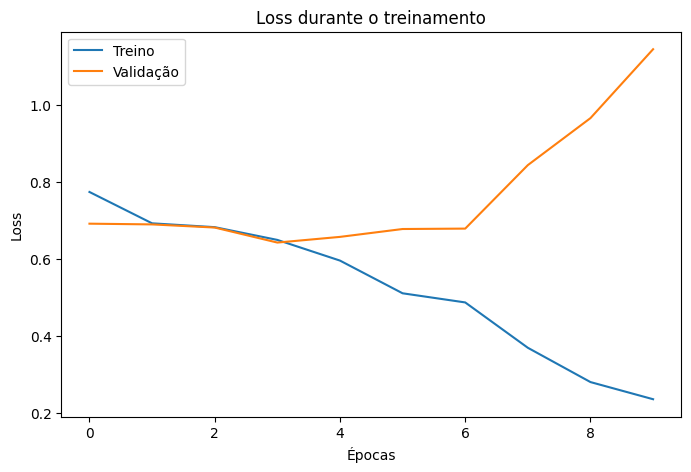

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Loss durante o treinamento")
plt.legend()

plt.show()

# ETAPA 18 — GRÁFICO DA ACURÁCIA

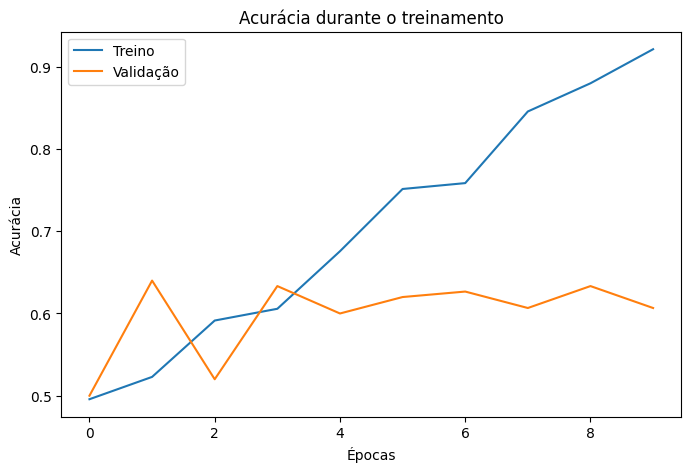

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")

plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Acurácia durante o treinamento")
plt.legend()

plt.show()

# ETAPA 19 — IDENTIFICAR A MELHOR ÉPOCA

In [20]:
melhor_epoca = np.argmin(history.history["val_loss"]) + 1
melhor_val_loss = np.min(history.history["val_loss"])

print("Melhor época:", melhor_epoca)
print("Menor val_loss:", melhor_val_loss)

Melhor época: 4
Menor val_loss: 0.6429122090339661


# ETAPA 20 — CARREGAR O MELHOR MODELO

In [21]:
melhor_modelo = load_model("/content/melhor_modelo.keras")

print("Melhor modelo carregado!")

Melhor modelo carregado!


# ETAPA 21 — AVALIAÇÃO FINAL COM O CONJUNTO DE TESTE

In [22]:
# Somente agora usamos o conjunto de teste.
#
# Essas imagens não foram utilizadas para treinar o modelo
# nem para escolher a melhor época.

test_loss, test_accuracy = melhor_modelo.evaluate(test_ds)

print("\nRESULTADO FINAL")
print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)
print("Acurácia no teste (%):", test_accuracy * 100)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - accuracy: 0.6733 - loss: 0.6266

RESULTADO FINAL
Loss no teste: 0.6265962719917297
Acurácia no teste: 0.6733333468437195
Acurácia no teste (%): 67.33333468437195


# ETAPA 22 — FAZER PREVISÕES NO CONJUNTO DE TESTE

In [23]:
# A sigmoid produz valores entre 0 e 1.
#
# Valor < 0.5 -> classe 0
# Valor >= 0.5 -> classe 1

imagens_lista = []
reais_lista = []
previstos_lista = []
probabilidades_lista = []

for imagens, labels in test_ds:

    probabilidades = melhor_modelo.predict(imagens, verbose=0).flatten()

    previsoes = (probabilidades >= 0.5).astype("int32")

    imagens_lista.extend(imagens.numpy())
    reais_lista.extend(labels.numpy())
    previstos_lista.extend(previsoes)
    probabilidades_lista.extend(probabilidades)

print("Previsões realizadas!")

Previsões realizadas!


# ETAPA 23 — LOCALIZAR OS ACERTOS E OS ERROS

In [24]:
acertos = []
erros = []

for i in range(len(reais_lista)):

    if reais_lista[i] == previstos_lista[i]:
        acertos.append(i)

    else:
        erros.append(i)

print("Quantidade de acertos:", len(acertos))
print("Quantidade de erros:", len(erros))

Quantidade de acertos: 101
Quantidade de erros: 49


# ETAPA 24 — MOSTRAR 5 ACERTOS

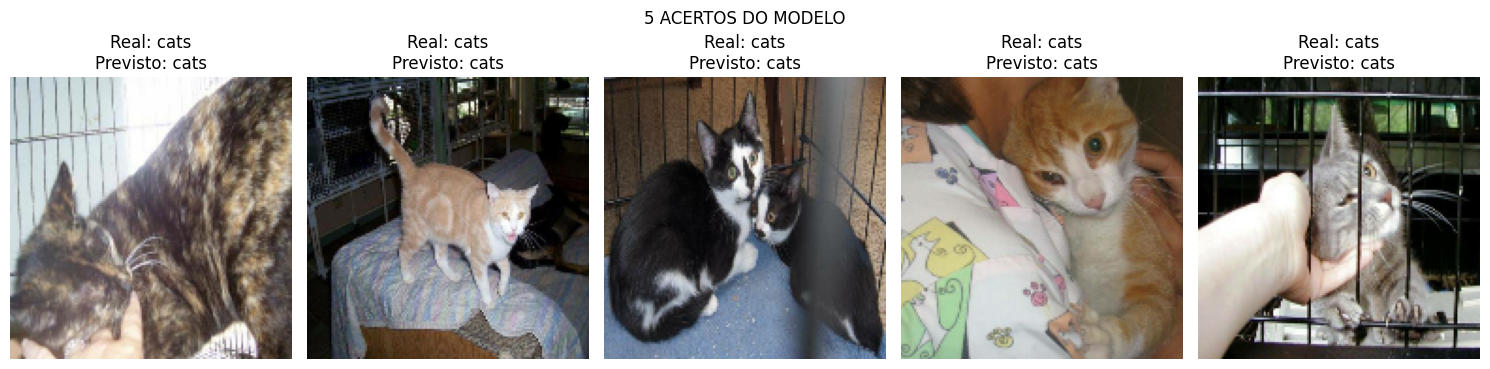

In [25]:
plt.figure(figsize=(15, 4))

for posicao, i in enumerate(acertos[:5]):

    plt.subplot(1, 5, posicao + 1)

    plt.imshow(imagens_lista[i].astype("uint8"))

    real = class_names[int(reais_lista[i])]
    previsto = class_names[int(previstos_lista[i])]

    plt.title(
        f"Real: {real}\n"
        f"Previsto: {previsto}"
    )

    plt.axis("off")

plt.suptitle("5 ACERTOS DO MODELO")
plt.tight_layout()
plt.show()

# ETAPA 25 — MOSTRAR 5 ERROS

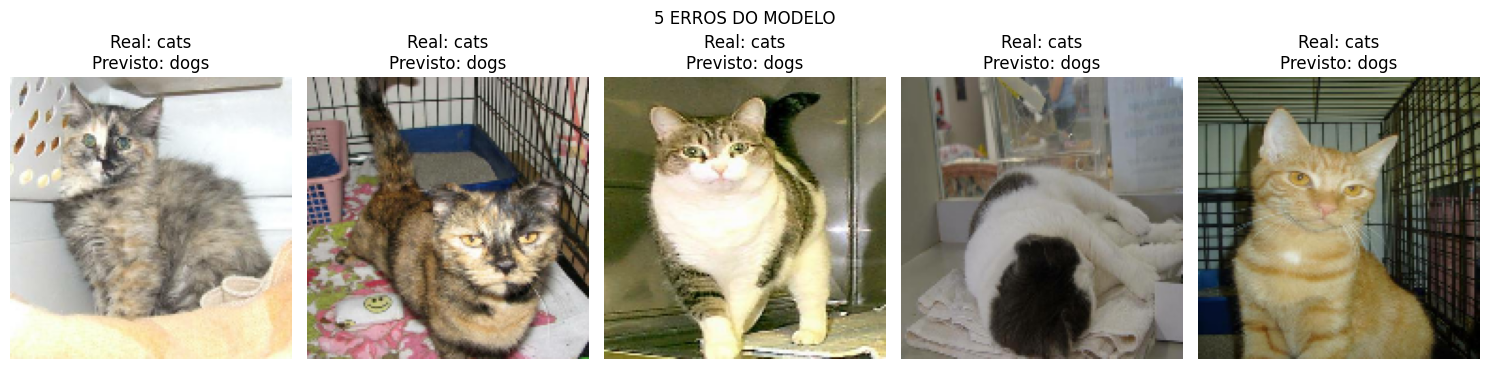

In [26]:
if len(erros) > 0:

    quantidade = min(5, len(erros))

    plt.figure(figsize=(15, 4))

    for posicao, i in enumerate(erros[:quantidade]):

        plt.subplot(1, quantidade, posicao + 1)

        plt.imshow(imagens_lista[i].astype("uint8"))

        real = class_names[int(reais_lista[i])]
        previsto = class_names[int(previstos_lista[i])]

        plt.title(
            f"Real: {real}\n"
            f"Previsto: {previsto}"
        )

        plt.axis("off")

    plt.suptitle("5 ERROS DO MODELO")
    plt.tight_layout()
    plt.show()

else:
    print("O modelo não apresentou erros no conjunto de teste.")

# FIM DA PIPELINE

# RESUMO:
#
# 1. Upload do ZIP
# 2. Descompactação
# 3. Identificação de gatos e cachorros
# 4. Separação:
#       70% treino
#       15% validação
#       15% teste
# 5. Carregamento das imagens
# 6. Criação da CNN
# 7. Treinamento
# 8. Checkpoint pelo menor val_loss
# 9. Gráficos de loss e acurácia
# 10. Carregamento do melhor modelo
# 11. Avaliação no conjunto de teste
# 12. Exibição de 5 acertos
# 13. Exibição de 5 erros